# Importing Libraries

In [15]:
# General libraries
import os
import random
import optuna
import shutil
import zipfile
import pathlib
import requests
import numpy as np
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm # tqdm for progress bar
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from timeit import default_timer as timer
from typing import Tuple, Dict, List


# torch
import torch
from torch import nn
from torchinfo import summary
from torchmetrics import Accuracy
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchmetrics.classification import BinaryConfusionMatrix, BinaryPrecision, BinaryRecall, BinaryF1Score, BinaryAccuracy

# torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import torchvision.transforms.functional as F
from torchvision.models import alexnet, vgg16

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [17]:
!nvidia-smi

Thu Mar 20 14:55:26 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...    Off |   00000000:01:00.0  On |                  N/A |
| 32%   39C    P8             10W /  320W |    1676MiB /  16376MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
# Setup path to data folder
data_path = Path('/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/')
base_dir = data_path / "deepfake_dataset"

In [19]:
def walk_through_dir(dir_path):
    """Walks through dir_path returning its contents."""
    total_images = 0
    for dirpath, dirnames, filenames in os.walk(dir_path):
        image_files = [f for f in filenames if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"There are {len(dirnames)} directories and {len(image_files)} images in '{dirpath}'.")
        total_images += len(image_files)
    print(f"\nTotal number of images found: {total_images}")

In [20]:
# Print directory structure
print("Analyzing dataset structure...")
walk_through_dir(base_dir)

Analyzing dataset structure...
There are 3 directories and 0 images in '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset'.
There are 2 directories and 0 images in '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Validation'.
There are 0 directories and 4852 images in '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Validation/Real'.
There are 0 directories and 4824 images in '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Validation/Fake'.
There are 2 directories and 0 images in '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Train'.
There are 0 directories and 44668 images in '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Train/Real'.
There are 0 directories and 45429 images in '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Train/Fake'.
There are 2 directories and 0 images in '/ho

In [21]:
# Path for train, validation and test data set
train_path = base_dir / "Train"
val_path = base_dir / "Validation"
test_path = base_dir / "Test"

# Print the paths to verify
print("\nDataset paths:")
print(f"Training data: {train_path}")
print(f"Validation data: {val_path}")
print(f"Testing data: {test_path}")

# Verify each directory exists
for path in [train_path, val_path, test_path]:
    if path.exists():
        print(f"\nAnalyzing {path.name} directory:")
        walk_through_dir(path)
    else:
        print(f"\nWarning: {path.name} directory not found at {path}")



Dataset paths:
Training data: /home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Train
Validation data: /home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Validation
Testing data: /home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Test

Analyzing Train directory:
There are 2 directories and 0 images in '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Train'.
There are 0 directories and 44668 images in '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Train/Real'.
There are 0 directories and 45429 images in '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Train/Fake'.

Total number of images found: 90097

Analyzing Validation directory:
There are 2 directories and 0 images in '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Validation'.
There are 0 directories and 4852 images in '/home/lab-25/Des

# Visualizing the Dataset

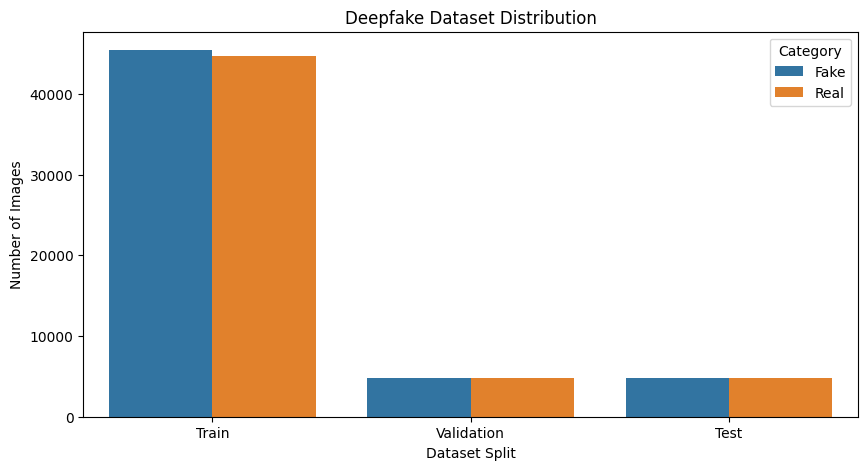

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

# Define the base path
base_path = '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset'
subsets = ['Train', 'Validation', 'Test']

# Dictionary to store counts
data_distribution = {subset: {'Fake': 0, 'Real': 0} for subset in subsets}

# Count images in each category
for subset in subsets:
    for category in ['Fake', 'Real']:
        category_path = os.path.join(base_path, subset, category)
        if os.path.exists(category_path):
            data_distribution[subset][category] = len(os.listdir(category_path))

# Plotting dataset distribution
plt.figure(figsize=(10, 5))
df_plot = []
for subset, counts in data_distribution.items():
    for category, count in counts.items():
        df_plot.append([subset, category, count])

sns.barplot(x=[x[0] for x in df_plot], y=[x[2] for x in df_plot], hue=[x[1] for x in df_plot])
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.title("Deepfake Dataset Distribution")
plt.legend(title="Category")
plt.show()



# Visualizing Some Sample Images

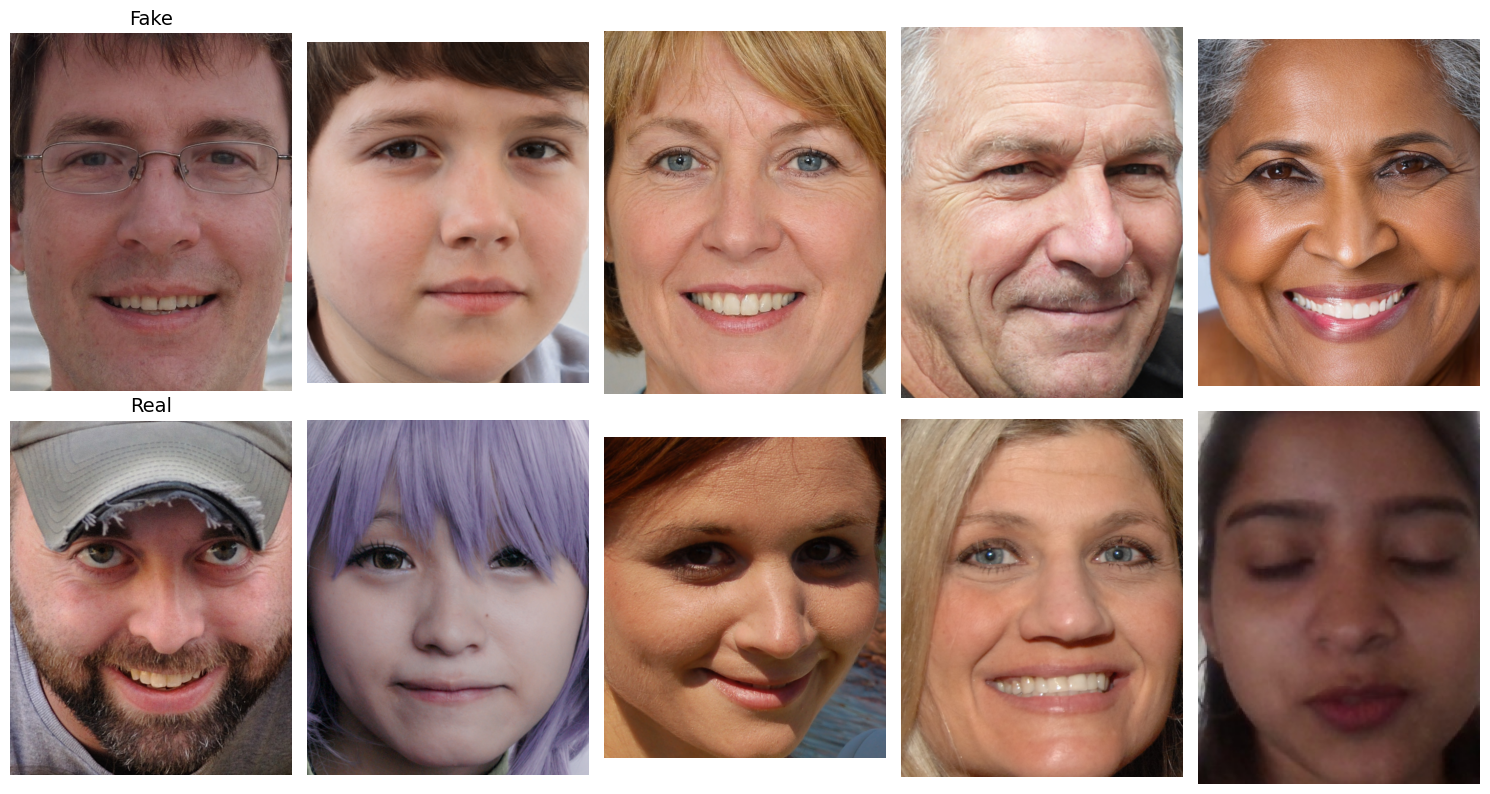

In [18]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision import transforms

# Define dataset path
dataset_path = '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Train'

# Get class names (Fake, Real)
class_names = sorted(os.listdir(dataset_path))

# Function to display random images from each class
def visualize_images(dataset_path, class_names, num_images=5):
    fig, axes = plt.subplots(len(class_names), num_images, figsize=(15, 8))

    for i, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)
        image_files = os.listdir(class_path)
        random_images = random.sample(image_files, min(num_images, len(image_files)))

        for j, img_file in enumerate(random_images):
            img_path = os.path.join(class_path, img_file)
            img = Image.open(img_path).convert("RGB")  # Open image

            # Display image
            axes[i, j].imshow(img)
            axes[i, j].axis('off')

            # Add title only to the first image in the row
            if j == 0:
                axes[i, j].set_title(class_name, fontsize=14)

    plt.tight_layout()
    plt.show()

# Call the function to visualize images
visualize_images(dataset_path, class_names, num_images=5)


# Visualizing some of Sample Images Generated from Liveportrait

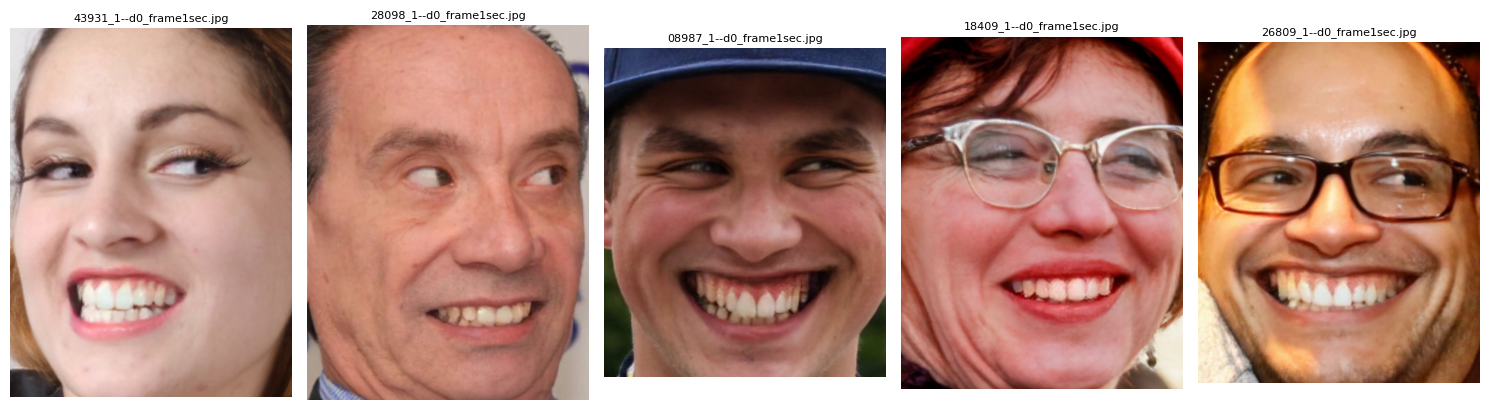

In [3]:
import os
import random
import re
import matplotlib.pyplot as plt
from PIL import Image

# Define dataset path
dataset_path = '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset/Train'

# Updated regex pattern to match "00048_1--d0_frame1sec.jpg" format
filename_pattern = re.compile(r'^\d+_\d+--\w+_frame\d+sec\.(png|jpg|jpeg)$')

# Function to find matching images
def find_matching_images(dataset_path, num_images=5):
    matching_images = []  # Store matching image paths

    # Loop through all subdirectories (e.g., Fake, Real)
    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue  # Skip non-folder files

        # Get all images that match the filename pattern
        image_files = [
            os.path.join(class_path, img)
            for img in os.listdir(class_path)
            if filename_pattern.match(img)  # Apply regex match
        ]
        matching_images.extend(image_files)

    # Shuffle and select a limited number of images
    random.shuffle(matching_images)
    return matching_images[:num_images]

# Function to visualize images
def visualize_images(image_paths):
    if not image_paths:
        print("No images found matching the specified filename format.")
        return
    
    fig, axes = plt.subplots(1, len(image_paths), figsize=(15, 5))
    if len(image_paths) == 1:
        axes = [axes]  # Ensure axes is iterable for a single image
    
    for ax, img_path in zip(axes, image_paths):
        img = Image.open(img_path).convert("RGB")  # Open image
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(os.path.basename(img_path), fontsize=8)  # Show filename

    plt.tight_layout()
    plt.show()

# Get and visualize matching images
matching_image_paths = find_matching_images(dataset_path, num_images=5)
visualize_images(matching_image_paths)


# Building Model

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import os
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

# Allow loading of truncated images without crashing
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Set device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True  # Optimize GPU performance

# Paths
base_path = '/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/deepfake_dataset'

# Custom Dataset Class to Skip Corrupted Images
class SafeImageFolder(ImageFolder):
    def __getitem__(self, index):
        while True:
            try:
                return super(SafeImageFolder, self).__getitem__(index)
            except (OSError, IOError, SyntaxError) as e:
                print(f"Skipping corrupted image at index {index}: {e}")
                index = (index + 1) % len(self.imgs)  # Skip to next image

# Optimized Data Transformations
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(128, scale=(0.7, 1.0)),
    transforms.ToTensor(),  # Convert to tensor before RandomErasing
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets using SafeImageFolder (skips bad images)
train_dataset = SafeImageFolder(f'{base_path}/Train', transform=train_transform)
valid_dataset = SafeImageFolder(f'{base_path}/Validation', transform=test_transform)
test_dataset = SafeImageFolder(f'{base_path}/Test', transform=test_transform)

# Verify class-to-index mapping
print("Train dataset class-to-index:", train_dataset.class_to_idx)

# Ensure the correct label mapping (0 -> Fake, 1 -> Real)
fake_label = train_dataset.class_to_idx.get('Fake', 0)
real_label = train_dataset.class_to_idx.get('Real', 1)

# Function to get balanced real and fake images
def get_fixed_balanced_indices(dataset):
    labels = [dataset.targets[i] for i in range(len(dataset))]
    num_fake = labels.count(fake_label)
    num_real = labels.count(real_label)
    num_samples_per_class = min(num_fake, num_real)

    indices_fake = [i for i in range(len(labels)) if labels[i] == fake_label]
    indices_real = [i for i in range(len(labels)) if labels[i] == real_label]

    selected_fake = random.sample(indices_fake, num_samples_per_class)
    selected_real = random.sample(indices_real, num_samples_per_class)

    return selected_fake + selected_real

# Create balanced subsets
train_subset = Subset(train_dataset, get_fixed_balanced_indices(train_dataset))
valid_subset = Subset(valid_dataset, get_fixed_balanced_indices(valid_dataset))
test_subset = Subset(test_dataset, get_fixed_balanced_indices(test_dataset))

# Create data loaders with memory optimization
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_subset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

Using device: cpu
Train dataset class-to-index: {'Fake': 0, 'Real': 1}



Epoch 1/6 Training:


Validation Batches: 100%|█████████████████████| 151/151 [02:38<00:00,  1.05s/it]


Epoch 1/6 - Train Loss: 0.346, Train Accuracy: 84.30%
Validation Loss: 0.177, Validation Accuracy: 92.91%
New best model saved!

Epoch 2/6 Training:


Validation Batches: 100%|█████████████████████| 151/151 [00:21<00:00,  7.08it/s]


Epoch 2/6 - Train Loss: 0.172, Train Accuracy: 93.17%
Validation Loss: 0.108, Validation Accuracy: 96.12%
New best model saved!

Epoch 3/6 Training:


...

Epoch 4/6 - Train Loss: 0.089, Train Accuracy: 96.65%
Validation Loss: 0.058, Validation Accuracy: 98.16%
New best model saved!

Epoch 5/6 Training:


Validation Batches: 100%|█████████████████████| 151/151 [02:21<00:00,  1.07it/s]


Epoch 5/6 - Train Loss: 0.072, Train Accuracy: 97.32%
Validation Loss: 0.042, Validation Accuracy: 98.51%
New best model saved!

Epoch 6/6 Training:


Validation Batches: 100%|█████████████████████| 151/151 [02:48<00:00,  1.12s/it]


Epoch 6/6 - Train Loss: 0.056, Train Accuracy: 97.94%
Validation Loss: 0.037, Validation Accuracy: 98.75%
New best model saved!

Training Complete!


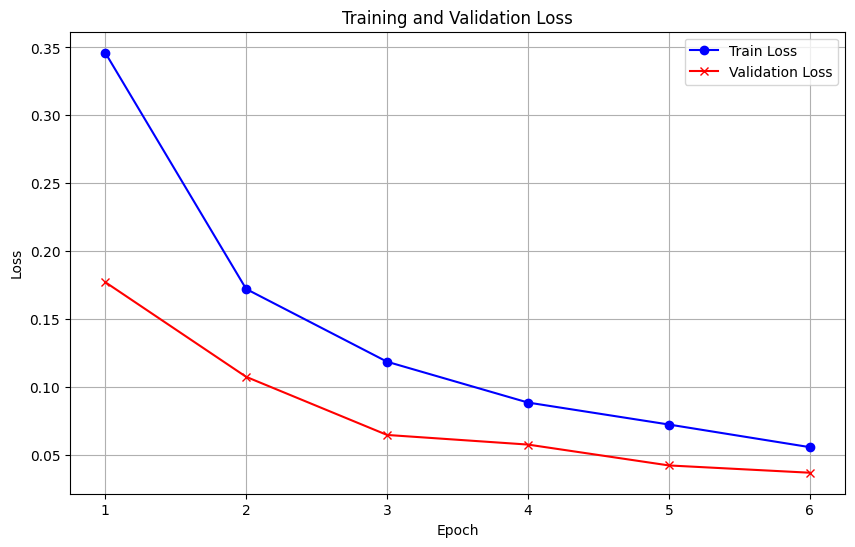

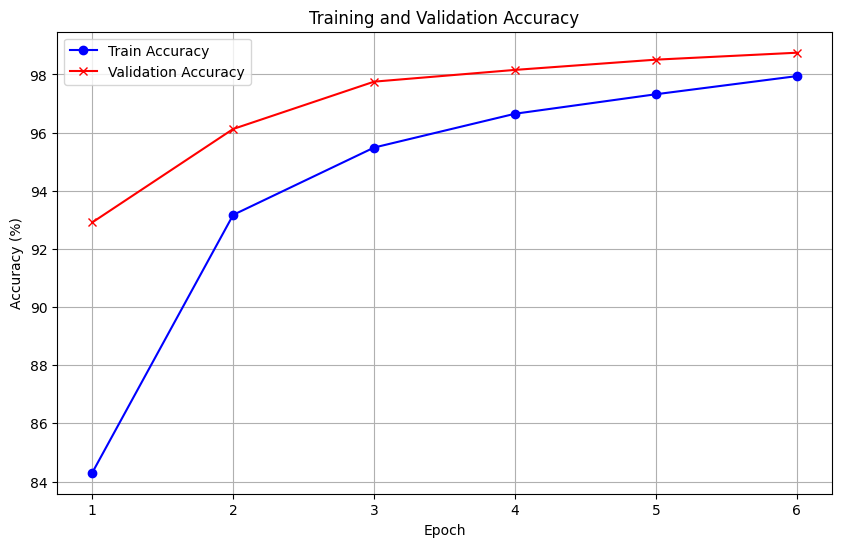

In [3]:
# Load EfficientNet-B3
classifier = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
classifier.classifier[1] = nn.Linear(classifier.classifier[1].in_features, 1)
classifier = classifier.to(device)

# Loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(classifier.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Enable mixed precision training
scaler = torch.cuda.amp.GradScaler()

# Store loss and accuracy values for plotting
train_losses, valid_losses = [], []
train_accuracies, valid_accuracies = [], []
best_valid_acc = 0

epochs = 6 # Define number of epochs dynamically if needed
for epoch in range(epochs):
    classifier.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    print(f"\nEpoch {epoch+1}/{epochs} Training:")
    for inputs, labels in tqdm(train_loader, desc="Training Batches"):
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True).float().view(-1, 1)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = classifier(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = (correct_train / total_train) * 100  # Training Accuracy
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation phase
    classifier.eval()
    correct_valid, total_valid, valid_loss = 0, 0, 0.0

    with torch.no_grad():
        for inputs, labels in tqdm(valid_loader, desc="Validation Batches"):
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True).float().view(-1, 1)
            outputs = classifier(inputs)
            loss = criterion(outputs, labels)

            valid_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5
            correct_valid += (preds == labels).sum().item()
            total_valid += labels.size(0)

    valid_loss /= len(valid_loader)
    valid_acc = (correct_valid / total_valid) * 100  # Validation Accuracy
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_acc)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.3f}, Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Loss: {valid_loss:.3f}, Validation Accuracy: {valid_acc:.2f}%")

    scheduler.step()

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(classifier.state_dict(), 'best_model.pth')
        print("New best model saved!")

print("\nTraining Complete!")

# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(range(1, epochs + 1), valid_losses, label='Validation Loss', color='red', marker='x')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot training accuracy
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy', color='blue', marker='o')
plt.plot(range(1, epochs + 1), valid_accuracies, label='Validation Accuracy', color='red', marker='x')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


# Loading The Model

In [3]:
import torch
import torch.nn as nn
from torchvision import models

# Set the device (use 'cuda' if available, otherwise fallback to 'cpu')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the model architecture
classifier = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
classifier.classifier[1] = nn.Linear(classifier.classifier[1].in_features, 1)
classifier = classifier.to(device)

# Load trained weights
classifier.load_state_dict(torch.load("best_model.pth", map_location=device))
classifier.eval()  # Set the model to evaluation mode
print("Model Loaded Successfully!")


Model Loaded Successfully!


# Testing On The Test Dataset

In [5]:
correct_test, total_test, test_loss = 0, 0, 0.0
test_criterion = nn.BCEWithLogitsLoss()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing Batches"):
        inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)
        outputs = classifier(inputs)
        loss = test_criterion(outputs, labels)

        test_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

test_loss /= len(test_loader)
test_acc = (correct_test / total_test) * 100

print(f"Test Loss: {test_loss:.3f}, Test Accuracy: {test_acc:.2f}%")


Testing Batches: 100%|████████████████████████| 151/151 [04:11<00:00,  1.67s/it]

Test Loss: 0.029, Test Accuracy: 98.92%


# Confusion Metric and Classification Report

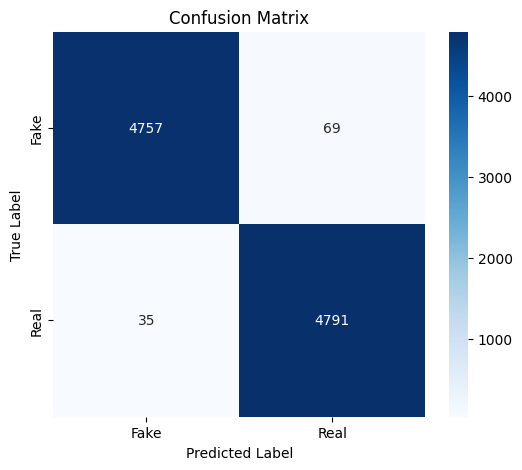


Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4826
        Real       0.99      0.99      0.99      4826

    accuracy                           0.99      9652
   macro avg       0.99      0.99      0.99      9652
weighted avg       0.99      0.99      0.99      9652



In [8]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load the trained model
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)  # Adjust output layer
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.to(device)
model.eval()

# Function to compute predictions and ground truth labels
def compute_confusion_matrix(model, dataloader):
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy().astype(int)

            y_true.extend(labels.cpu().numpy().astype(int))
            y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

# Get true and predicted labels
y_true, y_pred = compute_confusion_matrix(model, test_loader)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

# Display Confusion Matrix
class_names = ['Fake', 'Real']  # Adjust based on your dataset labels
plot_confusion_matrix(conf_matrix, class_names)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


# Testing on the Image not in Dataset(Image from thepersondoesntexist)

Prediction: Fake (Confidence: 1.00)


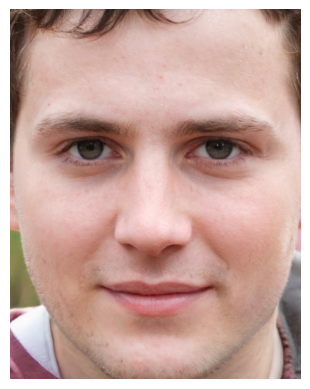

In [7]:
def predict_image(image_path, model, transform):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)  # Add batch dimension
    image = image.to(device)

    model.eval()
    with torch.no_grad():
        output = model(image)
        prediction = torch.sigmoid(output).item()

    if prediction > 0.5:
        print(f"Prediction: Real (Confidence: {prediction:.2f})")
    else:
        print(f"Prediction: Fake (Confidence: {1 - prediction:.2f})")

    plt.imshow(Image.open(image_path))
    plt.axis("off")
    plt.show()

# Example usage
image_path = "/home/lab-25/Music/ex_test1.jpeg"  # Change this to your image path
predict_image(image_path, classifier, test_transform)


# Testing on Real Images on which model was not trained 

Prediction: Real (Confidence: 1.00)


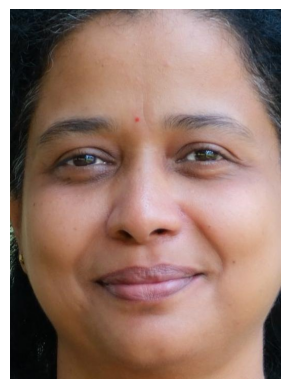

In [8]:
def predict_image(image_path, model, transform):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)  # Add batch dimension
    image = image.to(device)

    model.eval()
    with torch.no_grad():
        output = model(image)
        prediction = torch.sigmoid(output).item()

    if prediction > 0.5:
        print(f"Prediction: Real (Confidence: {prediction:.2f})")
    else:
        print(f"Prediction: Fake (Confidence: {1 - prediction:.2f})")

    plt.imshow(Image.open(image_path))
    plt.axis("off")
    plt.show()

# Example usage
image_path = "/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/data/dataset/facex/Anupama-1-scaled.jpg_face_1.jpg"  # Change this to your image path
predict_image(image_path, classifier, test_transform)


# Testing on the Rashmika Mandanna Indian actress


Prediction: Fake (Confidence: 0.60)


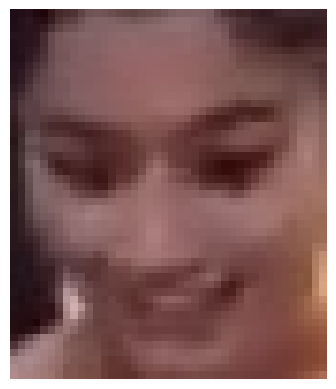

In [16]:
def predict_image(image_path, model, transform):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)  # Add batch dimension
    image = image.to(device)

    model.eval()
    with torch.no_grad():
        output = model(image)
        prediction = torch.sigmoid(output).item()

    if prediction > 0.5:
        print(f"Prediction: Real (Confidence: {prediction:.2f})")
    else:
        print(f"Prediction: Fake (Confidence: {1 - prediction:.2f})")

    plt.imshow(Image.open(image_path))
    plt.axis("off")
    plt.show()

# Example usage
image_path = "/home/lab-25/Desktop/Ml/Deep Learning/Deepfake/Extracted_Faces/Fake_Video1/face_40_0.jpg"  # Change this to your image path
predict_image(image_path, classifier, test_transform)


# Testing On Faculty Image 

Prediction: Real (Confidence: 0.89)


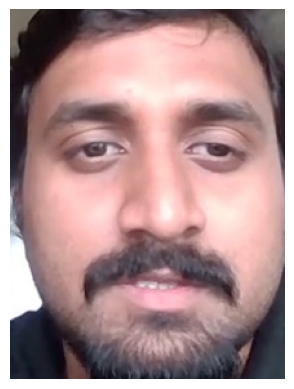

In [12]:
def predict_image(image_path, model, transform):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)  # Add batch dimension
    image = image.to(device)

    model.eval()
    with torch.no_grad():
        output = model(image)
        prediction = torch.sigmoid(output).item()

    if prediction > 0.5:
        print(f"Prediction: Real (Confidence: {prediction:.2f})")
    else:
        print(f"Prediction: Fake (Confidence: {1 - prediction:.2f})")

    plt.imshow(Image.open(image_path))
    plt.axis("off")
    plt.show()

# Example usage
image_path = "/home/lab-25/Desktop/DL_Project/DeepDetection_WebApp/Extracted_Frames/arnold_sachith_1997-05-04_Eng_qid2639_2024-06-21_11_07_02/frame_4.jpg"  # Change this to your image path
predict_image(image_path, classifier, test_transform)


# Testing the Model on Video that was Viral(Fake Video of Rashmika)

In [11]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models
from facenet_pytorch import MTCNN

# ------------------- Configuration -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Folders for extracted faces
FACE_FOLDER = "Extracted_Faces"
if not os.path.exists(FACE_FOLDER):
    os.makedirs(FACE_FOLDER)

# Load MTCNN for face detection
mtcnn = MTCNN(keep_all=False, device=device)

# Define image transformations for the deepfake detection model
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the deepfake detection model (EfficientNet-B3)
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 1)
model.load_state_dict(torch.load('best_model.pth', map_location=device))  # Ensure 'best_model.pth' exists
model.to(device)
model.eval()  # Set to evaluation mode

# ------------------- Face Extraction from Video -------------------
def extract_faces_from_video(video_path, frame_interval=10, max_faces=5):
    """
    Extracts and saves faces from a video using MTCNN.
    
    - frame_interval: Process every 'n' frames.
    - max_faces: Limit the number of extracted faces.
    
    Returns:
    - faces (list of NumPy arrays)
    - path to folder where faces are saved
    """
    cap = cv2.VideoCapture(video_path)
    faces = []
    frame_count = 0
    video_name = os.path.splitext(os.path.basename(video_path))[0]  # Extract video name

    video_face_folder = os.path.join(FACE_FOLDER, video_name)
    if not os.path.exists(video_face_folder):
        os.makedirs(video_face_folder)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret or len(faces) >= max_faces:
            break  # Stop if video ends or enough faces are extracted

        if frame_count % frame_interval == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert to RGB
            box, prob = mtcnn.detect(frame_rgb)  # Detect faces

            if box is not None:
                for i, (b, p) in enumerate(zip(box, prob)):
                    if p >= 0.9:  # High confidence threshold
                        x1, y1, x2, y2 = map(int, b)
                        face = frame_rgb[y1:y2, x1:x2]  # Crop face

                        if face.size > 0:
                            face_filename = os.path.join(video_face_folder, f"face_{frame_count}_{i}.jpg")
                            cv2.imwrite(face_filename, cv2.cvtColor(face, cv2.COLOR_RGB2BGR))  # Save face
                            faces.append(face)

        frame_count += 1

    cap.release()
    return faces, video_face_folder  # Return folder path

# ------------------- Deepfake Detection -------------------
def predict_face(face, model):
    """
    Runs deepfake detection on a single extracted face.

    Returns:
    - Deepfake confidence score (0 to 1)
    """
    image = Image.fromarray(face)
    image = transform(image).unsqueeze(0).to(device)  # Preprocess

    model.eval()
    with torch.no_grad():
        output = model(image)
        prediction = torch.sigmoid(output).item()  # Get probability

    return prediction

def predict_video(video_path, model):
    """
    Extracts faces from a video and predicts deepfake probability.
    
    - Extracted faces are stored in 'Extracted_Faces/[video_name]/'
    - Predictions are averaged over all detected faces.
    
    Returns:
    - Final classification: "Real" or "Fake"
    - Confidence score
    """
    faces, face_folder = extract_faces_from_video(video_path)
    
    if not faces:
        print("No face detected in the video.")
        return "No Face Found", 0, face_folder
    
    predictions = [predict_face(face, model) for face in faces]

    avg_prediction = np.mean(predictions) if predictions else 0.5  # Default to uncertain
    classification = "Real" if avg_prediction > 0.5 else "Fake"
    confidence = round(avg_prediction * 100 if classification == "Real" else (1 - avg_prediction) * 100)

    print(f"Final Prediction: {classification} (Confidence: {confidence}%)")
    
    return classification, confidence, face_folder

# ------------------- Run Example -------------------
if __name__ == "__main__":
    video_path = "/home/lab-25/Videos/fac/Fake_Video1.mp4"  # Change this to your video path
    result, confidence, saved_folder = predict_video(video_path, model)
    
    print("\n=== Prediction Result ===")
    print(f"Video: {video_path}")
    print(f"Prediction: {result}")
    print(f"Confidence: {confidence}%")
    print(f"Extracted Faces Saved At: {saved_folder}")


Final Prediction: Fake (Confidence: 77%)

=== Prediction Result ===
Video: /home/lab-25/Videos/fac/Fake_Video1.mp4
Prediction: Fake
Confidence: 77%
Extracted Faces Saved At: Extracted_Faces/Fake_Video1


# Testing on the Image Gen

Prediction: Fake (Confidence: 0.61)


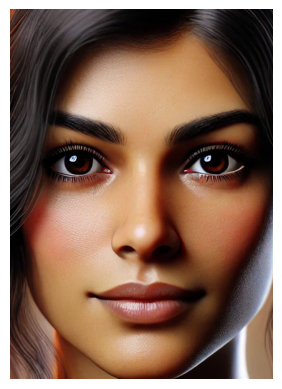

In [17]:
def predict_image(image_path, model, transform):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)  # Add batch dimension
    image = image.to(device)

    model.eval()
    with torch.no_grad():
        output = model(image)
        prediction = torch.sigmoid(output).item()

    if prediction > 0.5:
        print(f"Prediction: Real (Confidence: {prediction:.2f})")
    else:
        print(f"Prediction: Fake (Confidence: {1 - prediction:.2f})")

    plt.imshow(Image.open(image_path))
    plt.axis("off")
    plt.show()

# Example usage
image_path = "/home/lab-25/Desktop/DL_Project/DeepDetection_WebApp/Extracted_Frames/DALL·E 2025-03-19 15.24.01 - A realistic portrait of an Indian person with warm brown skin, dark expressive eyes, and black hair. The person is wearing traditional Indian attire, .webp"  # Change this to your image path
predict_image(image_path, classifier, test_transform)
